<div>
Olá, Micaela!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. Essa versão do seu trabalho ficou muito boa! Espero que as sugestões sejam relevantes para projetos futuros. Como sugestão geral, considere organizar o seu notebook de forma a refletir a descrição do projeto. 
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Sprint 9 — Projeto: Priorização de Hipóteses e Análise de Teste A/B

**Objetivo:**  
1) Priorizar hipóteses com ICE e RICE.  
2) Analisar o teste A/B (receita, ticket médio, conversão, anomalias, significância estatística) e tomar uma decisão.

**Datasets:**
- `/datasets/hypotheses_us.csv`
- `/datasets/orders_us.csv`
- `/datasets/visits_us.csv`


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 200)

plt.rcParams['figure.figsize'] = (12, 6)


## 1. Carregamento dos dados

Nesta etapa, carregamos os três conjuntos de dados fornecidos e fazemos uma primeira inspeção visual para entender a estrutura das tabelas.


In [3]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

display(hypotheses.head())
display(orders.head())
display(visits.head())


,Hypothesis;Reach;Impact;Confidence;Effort
0,Add two new channels for attracting traffic. This will bring 30% more users;3;10;8;6
1,Launch your own delivery service. This will shorten delivery time;2;5;4;10
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size;8;3;7;3
3,Change the category structure. This will increase conversion since users will find the products they want more quickly;8;3;3;8
4,Change the background color on the main page. This will increase user engagement;3;1;1;1


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente. Dica: aqui você poderia usar o separador `;` para carregar os dados diretamente através do método `.read_csv()`, sem precisar fazer o `split` abaixo
- O import das bibliotecas foi feito de forma correta e em uma célula separada
- Como sugestão, você poderia usar o método `describe()` aqui também para exibir as estatísticas descritivas do conjunto de dados

</div>

## 2. Inspeção inicial dos dados

Vamos verificar:
- tipos de dados
- valores ausentes
- linhas duplicadas

Isso garante que os dados estão prontos para análise ou indica o que precisa ser corrigido.


In [4]:
def data_check(df, name):
    print(f'--- {name} ---')
    df.info()
    print('\nDuplicadas:', df.duplicated().sum())
    print('\nValores ausentes (%):')
    display((df.isna().mean() * 100).round(2))
    print('\nDescrição:')
    display(df.describe(include='all').T)

data_check(hypotheses, 'hypotheses')
data_check(orders, 'orders')
data_check(visits, 'visits')


--- hypotheses ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Hypothesis;Reach;Impact;Confidence;Effort  9 non-null      object
dtypes: object(1)
memory usage: 200.0+ bytes

Duplicadas: 0

Valores ausentes (%):


Hypothesis;Reach;Impact;Confidence;Effort    0.0
dtype: float64


Descrição:


,count,unique,top,freq
Hypothesis;Reach;Impact;Confidence;Effort,9,9,Add a subscription form to all the main pages. This will help you compile a mailing list;10;7;8;5,1


--- orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB

Duplicadas: 0

Valores ausentes (%):


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transactionId,1197.0,NaN,NaN,NaN,2155621385.529657,1229084904.760058,1062393.0,1166775572.0,2145193898.0,3237740112.0,4293855558.0
visitorId,1197.0,NaN,NaN,NaN,2165960143.099415,1236014192.14687,5114589.0,1111826046.0,2217984702.0,3177606451.0,4283872382.0
date,1197,31,2019-08-05,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenue,1197.0,NaN,NaN,NaN,131.491646,603.004729,5.0,20.8,50.2,130.4,19920.4
group,1197,2,B,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- visits ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB

Duplicadas: 0

Valores ausentes (%):


date      0.0
group     0.0
visits    0.0
dtype: float64


Descrição:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,62,31,2019-08-09,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,62,2,B,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visits,62.0,NaN,NaN,NaN,607.290323,114.40056,361.0,534.0,624.5,710.5,770.0


## 3. Padronização dos dados

Nesta etapa:
- padronizamos os nomes das colunas (minúsculas)
- garantimos que as datas estejam no formato correto
- ajustamos o nome da coluna de hipótese, se necessário


In [5]:
# padronizar nomes das colunas
hypotheses.columns = [c.lower().strip() for c in hypotheses.columns]
orders.columns = [c.lower().strip() for c in orders.columns]
visits.columns = [c.lower().strip() for c in visits.columns]

# normalizar nome da coluna de hipótese
if 'hypotheses' in hypotheses.columns and 'hypothesis' not in hypotheses.columns:
    hypotheses = hypotheses.rename(columns={'hypotheses': 'hypothesis'})

# converter datas
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

display(hypotheses.head())
display(orders.head())
display(visits.head())


,hypothesis;reach;impact;confidence;effort
0,Add two new channels for attracting traffic. This will bring 30% more users;3;10;8;6
1,Launch your own delivery service. This will shorten delivery time;2;5;4;10
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size;8;3;7;3
3,Change the category structure. This will increase conversion since users will find the products they want more quickly;8;3;3;8
4,Change the background color on the main page. This will increase user engagement;3;1;1;1


,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


## 4. Validação do teste A/B

Antes da análise, é obrigatório verificar se há usuários que participaram **dos dois grupos (A e B)**.
Isso viola a lógica do teste A/B e esses usuários precisam ser removidos.


In [6]:
# identificar visitantes que aparecem em mais de um grupo
users_in_both_groups = (
    orders.groupby('visitorid')['group']
    .nunique()
    .reset_index()
    .query('group > 1')
)

print('Número de visitantes em ambos os grupos:', users_in_both_groups.shape[0])

users_in_both_groups.head()


Número de visitantes em ambos os grupos: 58


,visitorid,group
2,8300375,2
44,199603092,2
51,232979603,2
55,237748145,2
66,276558944,2


Visitantes que aparecem nos dois grupos distorcem os resultados.
A abordagem correta é **remover completamente esses usuários** da análise.


In [7]:
# remover visitantes problemáticos
bad_visitors = set(users_in_both_groups['visitorid'])

orders_clean = orders[~orders['visitorid'].isin(bad_visitors)].copy()

print('Pedidos antes da limpeza:', orders.shape[0])
print('Pedidos depois da limpeza:', orders_clean.shape[0])


Pedidos antes da limpeza: 1197
Pedidos depois da limpeza: 1016


# Parte 1 — Priorização de Hipóteses

O dataset `hypotheses_us.csv` contém hipóteses com as métricas:
- `Reach` (alcance)
- `Impact` (impacto)
- `Confidence` (confiança)
- `Effort` (esforço)

Vamos priorizar usando dois frameworks:
- **ICE** = (Impact × Confidence) / Effort  
- **RICE** = (Reach × Impact × Confidence) / Effort


## 5. Priorização com ICE

O framework ICE é utilizado para priorizar hipóteses com base em três fatores:
- **Impact** — impacto potencial nos usuários
- **Confidence** — nível de confiança na hipótese
- **Effort** — esforço necessário para implementá-la

A fórmula do ICE é:

ICE = (Impact × Confidence) / Effort

Esse método **não considera o alcance (Reach)**.


In [11]:
# carregar novamente o dataset de hipóteses com separador correto
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

# padronizar nomes das colunas
hypotheses.columns = hypotheses.columns.str.lower().str.strip()

# calcular ICE
hypotheses['ice'] = (
    hypotheses['impact'] * hypotheses['confidence']
) / hypotheses['effort']

# ordenar por prioridade
ice_rank = (
    hypotheses[['hypothesis', 'reach', 'impact', 'confidence', 'effort', 'ice']]
    .sort_values('ice', ascending=False)
)

display(ice_rank)


,hypothesis,reach,impact,confidence,effort,ice
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3,7.000000
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10,2.000000
5,Add a customer review page. This will increase the number of orders,3,2,2,3,1.333333
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8,1.125000
4,Change the background color on the main page. This will increase user engagement,3,1,1,1,1.000000


### Conclusão — ICE

Com base no framework ICE, as hipóteses com maior prioridade são aquelas
que apresentam **alto impacto e alta confiança**, exigindo **baixo esforço**.

Como o ICE não considera o alcance (Reach), algumas hipóteses com potencial
de afetar poucos usuários podem aparecer no topo do ranking.


## 6. Priorização com RICE

O framework RICE amplia o ICE ao incluir o fator **Reach (alcance)**, ou seja,
quantos usuários serão impactados pela hipótese.

A fórmula do RICE é:

RICE = (Reach × Impact × Confidence) / Effort

Esse método tende a priorizar hipóteses que afetam **mais usuários**, mesmo que
o impacto individual não seja tão alto.


In [12]:
# calcular RICE
hypotheses['rice'] = (
    hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']
) / hypotheses['effort']

# ordenar por prioridade
rice_rank = (
    hypotheses[['hypothesis', 'reach', 'impact', 'confidence', 'effort', 'rice']]
    .sort_values('rice', ascending=False)
)

display(rice_rank)


,hypothesis,reach,impact,confidence,effort,rice
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3,40.0
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8,9.0
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10,4.0
5,Add a customer review page. This will increase the number of orders,3,2,2,3,4.0
4,Change the background color on the main page. This will increase user engagement,3,1,1,1,3.0


### Conclusão — RICE

O ranking RICE tende a favorecer hipóteses com **maior alcance (Reach)**,
pois elas impactam um número maior de usuários.

Isso pode alterar significativamente a priorização em comparação com o ICE,
especialmente quando existem hipóteses com alto impacto mas baixo alcance.


## 7. Comparação entre ICE e RICE

Nesta etapa, comparamos os rankings obtidos pelos frameworks ICE e RICE
para entender como a inclusão do fator **Reach** altera a priorização
das hipóteses.


In [13]:
# criar tabela de comparação
comparison = hypotheses[['hypothesis', 'ice', 'rice']].copy()

comparison['ice_rank'] = comparison['ice'].rank(ascending=False, method='min')
comparison['rice_rank'] = comparison['rice'].rank(ascending=False, method='min')

comparison['rank_change'] = comparison['ice_rank'] - comparison['rice_rank']

comparison = comparison.sort_values('rank_change', ascending=False)

display(comparison)


,hypothesis,ice,rice,ice_rank,rice_rank,rank_change
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000,56.0,5.0,2.0,3.0
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000,9.0,8.0,6.0,2.0
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000,112.0,3.0,1.0,2.0
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000,40.0,4.0,3.0,1.0
4,Change the background color on the main page. This will increase user engagement,1.000000,3.0,9.0,9.0,0.0
5,Add a customer review page. This will increase the number of orders,1.333333,4.0,7.0,7.0,0.0
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333,40.0,2.0,3.0,-1.0
1,Launch your own delivery service. This will shorten delivery time,2.000000,4.0,6.0,7.0,-1.0
8,Launch a promotion that gives users discounts on their birthdays,16.200000,16.2,1.0,5.0,-4.0


### Conclusão — ICE vs RICE

A principal diferença entre ICE e RICE é a inclusão do fator **Reach** no RICE.

Hipóteses com **alto alcance** tendem a subir no ranking RICE,
mesmo que não apresentem o maior impacto individual.

Por outro lado, hipóteses com alto impacto, mas que afetam poucos usuários,
podem perder prioridade quando o alcance é considerado.

Isso torna o RICE mais adequado quando o objetivo é maximizar o impacto
no nível do negócio.


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os indicadores `ICE` e `RICE` foram calculados corretamente para estimar o impacto de hipóteses. 
- As hipóteses foram ordenadas corretamente pelos scores criados!
</div>

# Parte 2 — Análise do Teste A/B

Nesta parte, analisamos os resultados do teste A/B utilizando os dados
de pedidos (`orders_us.csv`) e visitas (`visits_us.csv`).

O objetivo é avaliar o impacto do experimento em:
- receita
- tamanho médio do pedido
- taxa de conversão


## 8. Preparação dos dados para análise

Vamos:
- agrupar pedidos por data e grupo
- calcular métricas diárias
- preparar valores acumulados para análise gráfica


In [14]:
# agrupar pedidos por data e grupo
orders_daily = (
    orders_clean
    .groupby(['date', 'group'])
    .agg(
        orders=('transactionid', 'nunique'),
        buyers=('visitorid', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# agrupar visitas por data e grupo
visits_daily = (
    visits
    .groupby(['date', 'group'])
    .agg(visits=('visits', 'sum'))
    .reset_index()
)

# unir pedidos e visitas
daily_data = orders_daily.merge(
    visits_daily,
    on=['date', 'group'],
    how='left'
)

# ordenar
daily_data = daily_data.sort_values(['group', 'date'])

display(daily_data.head())


,date,group,orders,buyers,revenue,visits
0,2019-08-01,A,23,19,2266.6,719
2,2019-08-02,A,19,18,1468.3,619
4,2019-08-03,A,24,24,1815.2,507
6,2019-08-04,A,11,11,675.5,717
8,2019-08-05,A,22,22,1398.0,756


## 9. Receita acumulada por grupo

Vamos calcular a receita acumulada ao longo do tempo para cada grupo (A e B)
e construir um gráfico.

Esse gráfico ajuda a identificar:
- qual grupo gera mais receita ao longo do teste
- se há estabilidade ou grandes oscilações (possíveis anomalias)


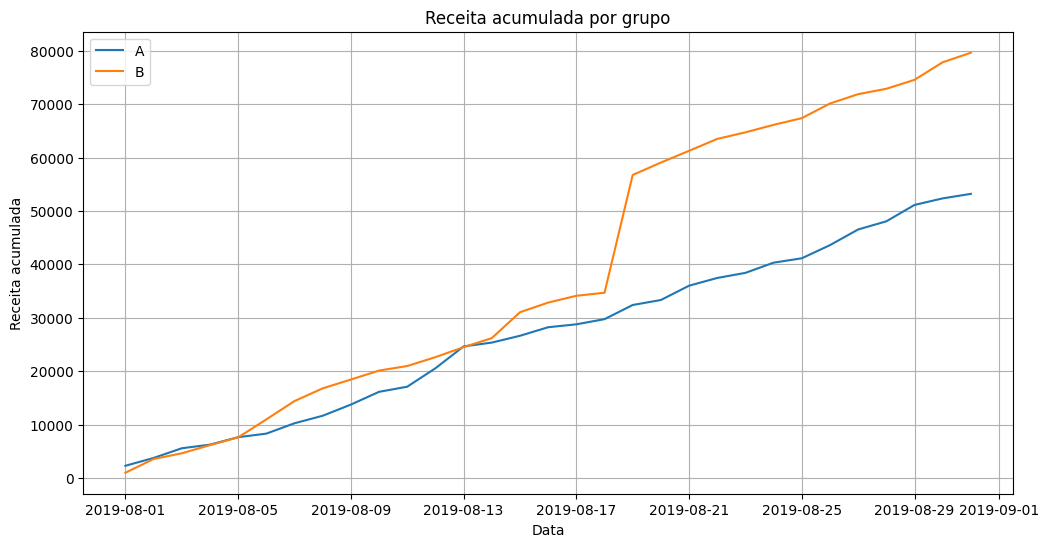

In [15]:
# calcular receita acumulada e pedidos acumulados
daily_data['cum_revenue'] = daily_data.groupby('group')['revenue'].cumsum()
daily_data['cum_orders'] = daily_data.groupby('group')['orders'].cumsum()

# gráfico da receita acumulada
for g in ['A', 'B']:
    temp = daily_data[daily_data['group'] == g]
    plt.plot(temp['date'], temp['cum_revenue'], label=g)

plt.title('Receita acumulada por grupo')
plt.xlabel('Data')
plt.ylabel('Receita acumulada')
plt.legend()
plt.grid(True)
plt.show()


### Conclusões — Receita acumulada

Descreva o que o gráfico mostra:

- Se um grupo mantém a receita acumulada consistentemente acima do outro.
- Se existem **saltos bruscos** (podem indicar pedidos muito altos/anômalos).
- Se as curvas se cruzam frequentemente (instabilidade / ausência de tendência clara).

Com base no gráfico, formule hipóteses iniciais sobre qual grupo pode estar performando melhor em receita.


## 10. Tamanho médio acumulado do pedido por grupo

O tamanho médio acumulado do pedido é calculado como a razão entre
a receita acumulada e o número acumulado de pedidos.

Essa métrica ajuda a identificar diferenças no comportamento de compra
entre os grupos ao longo do tempo.


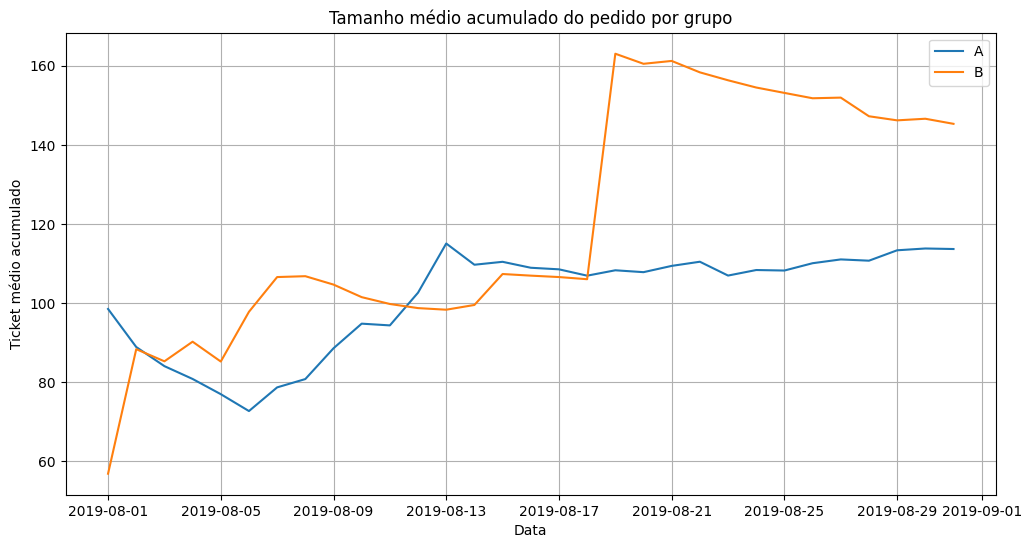

In [16]:
# calcular ticket médio acumulado
daily_data['cum_avg_order'] = (
    daily_data['cum_revenue'] / daily_data['cum_orders']
)

# gráfico do ticket médio acumulado
for g in ['A', 'B']:
    temp = daily_data[daily_data['group'] == g]
    plt.plot(temp['date'], temp['cum_avg_order'], label=g)

plt.title('Tamanho médio acumulado do pedido por grupo')
plt.xlabel('Data')
plt.ylabel('Ticket médio acumulado')
plt.legend()
plt.grid(True)
plt.show()


### Conclusões — Tamanho médio acumulado do pedido

Analise o gráfico observando:

- Qual grupo apresenta maior ticket médio ao longo do tempo.
- Se há grandes variações ou picos, o que pode indicar a presença de pedidos anômalos.
- Se a diferença entre os grupos é estável ou muda durante o experimento.

Essas observações ajudam a entender se o experimento impactou o valor médio dos pedidos.


## 11. Diferença relativa do tamanho médio acumulado do pedido

Nesta etapa, calculamos a diferença relativa do ticket médio acumulado
do grupo B em relação ao grupo A.

Isso facilita a visualização de:
- quando o grupo B supera o grupo A
- a magnitude dessa diferença ao longo do tempo


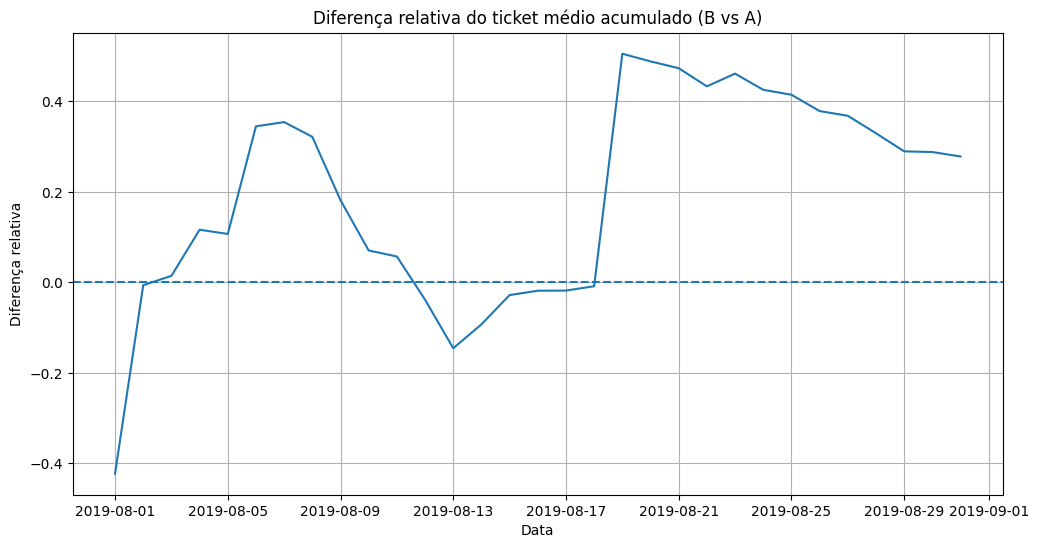

In [17]:
# pivot para calcular diferença relativa
avg_pivot = daily_data.pivot(
    index='date',
    columns='group',
    values='cum_avg_order'
)

relative_diff_avg = (avg_pivot['B'] / avg_pivot['A']) - 1

plt.plot(relative_diff_avg.index, relative_diff_avg)
plt.axhline(0, linestyle='--')
plt.title('Diferença relativa do ticket médio acumulado (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')
plt.grid(True)
plt.show()


### Conclusões — Diferença relativa do ticket médio

- Valores **acima de zero** indicam que o grupo B tem ticket médio maior que o grupo A.
- Valores **abaixo de zero** indicam o contrário.

Analise se a diferença:
- permanece estável ao longo do tempo
- apresenta oscilações significativas
- tende a se aproximar de zero

Esses padrões ajudam a avaliar se o efeito observado é consistente.


## 12. Taxa de conversão diária por grupo

A taxa de conversão diária é calculada como:

Conversão = (número de pedidos) / (número de visitas)

Vamos calcular a conversão diária para cada grupo e visualizar em um gráfico
para comparar o desempenho ao longo do período do teste.


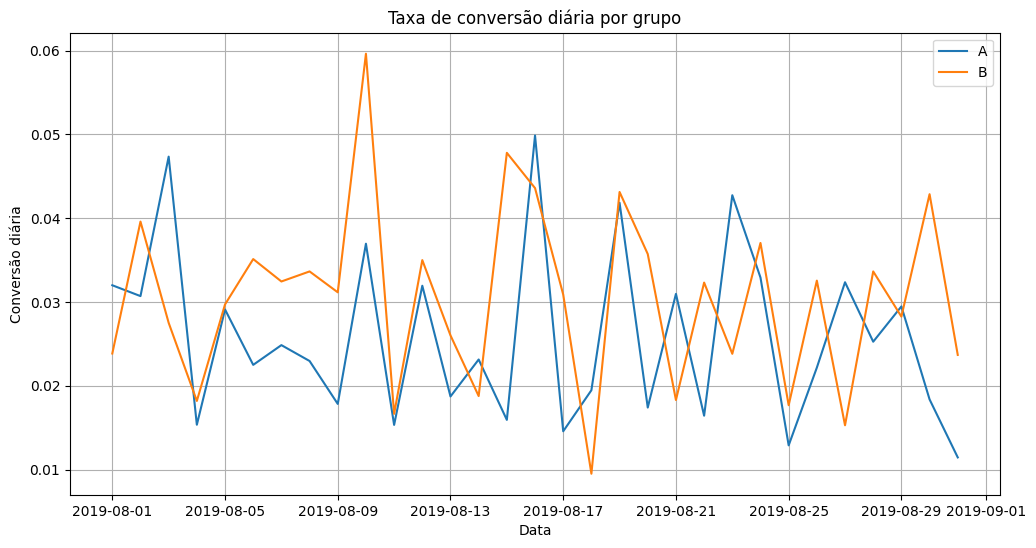

In [18]:
# calcular conversão diária
daily_data['conversion'] = daily_data['orders'] / daily_data['visits']

# gráfico da conversão diária
for g in ['A', 'B']:
    temp = daily_data[daily_data['group'] == g]
    plt.plot(temp['date'], temp['conversion'], label=g)

plt.title('Taxa de conversão diária por grupo')
plt.xlabel('Data')
plt.ylabel('Conversão diária')
plt.legend()
plt.grid(True)
plt.show()


### Conclusões — Conversão diária

Descreva a diferença entre os grupos observando:

- qual grupo apresenta conversão geralmente mais alta
- se há muita variação diária (normal em dados reais)
- se existe uma tendência consistente ao longo do tempo

O gráfico diário é útil para ver volatilidade, mas a análise cumulativa
(mais adiante) costuma ser mais confiável para tomada de decisão.


## 13. Diferença relativa da conversão cumulativa

A conversão cumulativa é mais estável do que a conversão diária,
pois reduz o efeito de flutuações pontuais.

Nesta etapa, calculamos a diferença relativa da conversão cumulativa
do grupo B em relação ao grupo A para avaliar o desempenho do experimento
ao longo do tempo.


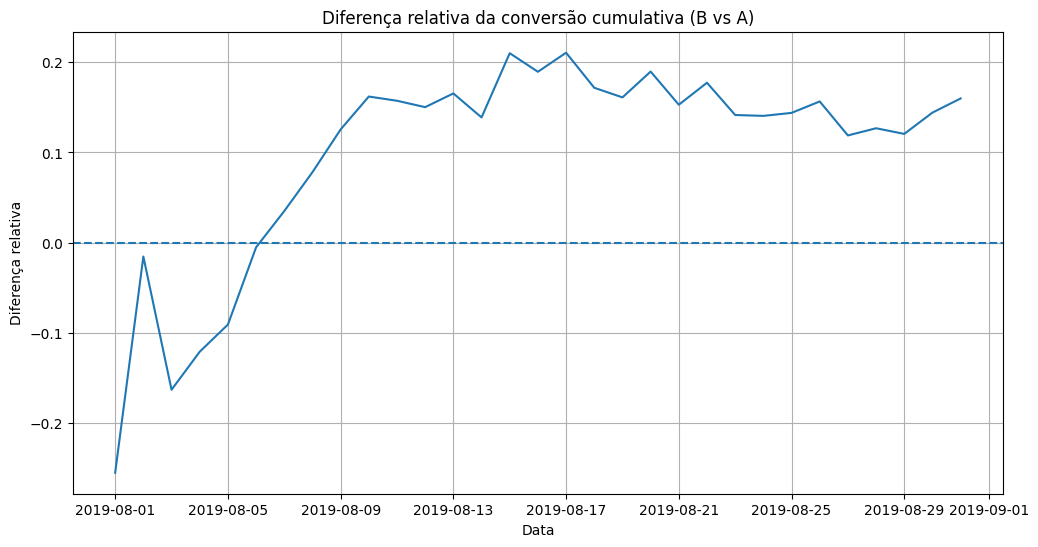

In [19]:
# calcular visitas e pedidos acumulados
daily_data['cum_visits'] = daily_data.groupby('group')['visits'].cumsum()
daily_data['cum_conversion'] = daily_data['cum_orders'] / daily_data['cum_visits']

# pivot para diferença relativa
conv_pivot = daily_data.pivot(
    index='date',
    columns='group',
    values='cum_conversion'
)

relative_diff_conv = (conv_pivot['B'] / conv_pivot['A']) - 1

# gráfico
plt.plot(relative_diff_conv.index, relative_diff_conv)
plt.axhline(0, linestyle='--')
plt.title('Diferença relativa da conversão cumulativa (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')
plt.grid(True)
plt.show()


### Conclusões — Diferença relativa da conversão cumulativa

- Valores acima de zero indicam conversão cumulativa maior no grupo B.
- Valores abaixo de zero indicam melhor desempenho do grupo A.

Se a diferença relativa se mantém estável ao longo do tempo,
isso sugere que o efeito observado é consistente
e não resultado de flutuações aleatórias.


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- [x] A receita cumulativa por grupo foi analisada
- [x] A diferença relativa do tamanho médio do pedido foi calculada
- [x] A conversão por grupo foi analisada
- [x] A conclusão foi apresentada

</div>

## 14. Análise de anomalias — número de pedidos por usuário

Antes de realizar os testes estatísticos, é importante identificar usuários
com comportamento atípico, como um número excessivamente alto de pedidos.

Esses usuários podem distorcer os resultados do teste A/B.
Para isso, vamos calcular os percentis 95 e 99 do número de pedidos por usuário.


In [20]:
# número de pedidos por usuário
orders_per_user = (
    orders_clean
    .groupby('visitorid')
    .agg(orders=('transactionid', 'nunique'))
    .reset_index()
)

# calcular percentis
p95_orders = np.percentile(orders_per_user['orders'], 95)
p99_orders = np.percentile(orders_per_user['orders'], 99)

print('Percentil 95 (pedidos por usuário):', p95_orders)
print('Percentil 99 (pedidos por usuário):', p99_orders)


Percentil 95 (pedidos por usuário): 1.0
Percentil 99 (pedidos por usuário): 2.0


### Definição de anomalias — pedidos por usuário

Usuários com um número de pedidos **acima do percentil 95**
são considerados anômalos.

Esse limite permite remover comportamentos extremos,
mantendo a maior parte dos dados representativos do comportamento normal dos usuários.


## 15. Análise de anomalias — preços dos pedidos

Além do número de pedidos por usuário, valores extremamente altos de pedidos
podem distorcer a análise do teste A/B.

Nesta etapa, analisamos a distribuição dos preços dos pedidos,
utilizando um gráfico de dispersão e os percentis 95 e 99.


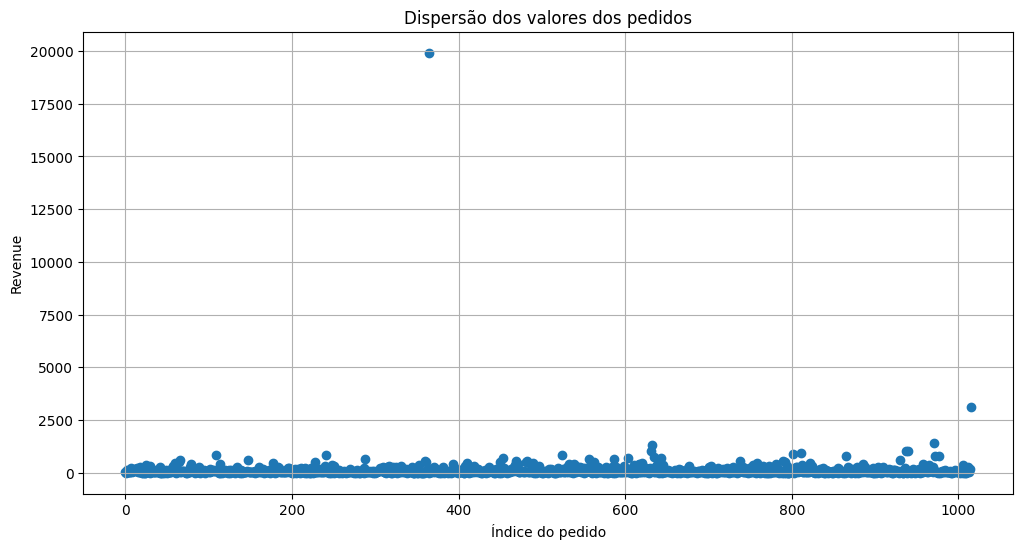

In [21]:
# gráfico de dispersão dos valores dos pedidos
plt.scatter(range(len(orders_clean)), orders_clean['revenue'])
plt.title('Dispersão dos valores dos pedidos')
plt.xlabel('Índice do pedido')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


In [22]:
# calcular percentis do valor dos pedidos
p95_revenue = np.percentile(orders_clean['revenue'], 95)
p99_revenue = np.percentile(orders_clean['revenue'], 99)

print('Percentil 95 (revenue):', p95_revenue)
print('Percentil 99 (revenue):', p99_revenue)


Percentil 95 (revenue): 414.275
Percentil 99 (revenue): 830.3


### Definição de anomalias — preços dos pedidos

Pedidos com valor **acima do percentil 95**
são considerados anômalos e podem influenciar desproporcionalmente
as métricas de receita e ticket médio.

Esses pedidos serão removidos na etapa de análise filtrada.


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Os percentis 95 e 99 foram calculados para o número de pedidos e preços. Sugestão: faça o cálculo por grupo também.
</div>

## 16. Significância estatística da conversão (dados brutos)

Nesta etapa, avaliamos se a diferença na taxa de conversão entre os grupos A e B
é estatisticamente significativa utilizando os **dados brutos**, sem remover anomalias.

O teste utilizado é o **Mann-Whitney U**, adequado para distribuições não normais.


In [23]:
# total de visitas por grupo
visits_by_group = visits.groupby('group')['visits'].sum()

# número de pedidos por usuário
orders_users = (
    orders_clean
    .groupby(['group', 'visitorid'])
    .agg(orders=('transactionid', 'nunique'))
    .reset_index()
)

# criar amostras com zeros para usuários que não compraram
sample_A = pd.concat([
    orders_users[orders_users['group'] == 'A']['orders'],
    pd.Series(0, index=np.arange(
        visits_by_group['A'] - orders_users[orders_users['group'] == 'A'].shape[0]
    ))
])

sample_B = pd.concat([
    orders_users[orders_users['group'] == 'B']['orders'],
    pd.Series(0, index=np.arange(
        visits_by_group['B'] - orders_users[orders_users['group'] == 'B'].shape[0]
    ))
])

print('Tamanho da amostra A:', len(sample_A))
print('Tamanho da amostra B:', len(sample_B))


Tamanho da amostra A: 18736
Tamanho da amostra B: 18916


In [24]:
alpha = 0.05

p_value = stats.mannwhitneyu(sample_A, sample_B, alternative='two-sided')[1]
relative_diff = sample_B.mean() / sample_A.mean() - 1

print('p-value:', p_value)
print('Diferença relativa (B vs A):', relative_diff)

if p_value < alpha:
    print('Diferença estatisticamente significativa.')
else:
    print('Não há evidência de diferença estatisticamente significativa.')


p-value: 0.011018084110014696
Diferença relativa (B vs A): 0.1597977924896936
Diferença estatisticamente significativa.


### Conclusões — Conversão (dados brutos)

Com base no teste estatístico aplicado aos dados brutos,
avaliamos se a diferença observada na conversão entre os grupos
pode ser atribuída ao efeito do experimento ou ao acaso.

Os resultados serão comparados posteriormente com a análise
utilizando dados filtrados.


## 17. Significância estatística do tamanho médio do pedido (dados brutos)

Nesta etapa, avaliamos se a diferença no tamanho médio do pedido
entre os grupos A e B é estatisticamente significativa,
utilizando os **dados brutos**, sem remoção de anomalias.

O teste estatístico utilizado é o **Mann-Whitney U**,
adequado para comparar distribuições não normais.


In [25]:
# separar valores dos pedidos por grupo
revenue_A = orders_clean[orders_clean['group'] == 'A']['revenue']
revenue_B = orders_clean[orders_clean['group'] == 'B']['revenue']

print('Pedidos grupo A:', len(revenue_A))
print('Pedidos grupo B:', len(revenue_B))


Pedidos grupo A: 468
Pedidos grupo B: 548


In [26]:
alpha = 0.05

p_value_rev = stats.mannwhitneyu(
    revenue_A,
    revenue_B,
    alternative='two-sided'
)[1]

relative_diff_rev = revenue_B.mean() / revenue_A.mean() - 1

print('p-value:', p_value_rev)
print('Diferença relativa do ticket médio (B vs A):', relative_diff_rev)

if p_value_rev < alpha:
    print('Diferença estatisticamente significativa.')
else:
    print('Não há evidência de diferença estatisticamente significativa.')


p-value: 0.8622329690015668
Diferença relativa do ticket médio (B vs A): 0.27834487693078414
Não há evidência de diferença estatisticamente significativa.


### Conclusões — Tamanho médio do pedido (dados brutos)

O teste estatístico aplicado aos dados brutos permite avaliar
se a diferença observada no tamanho médio dos pedidos
entre os grupos A e B é estatisticamente significativa.

Esses resultados serão comparados com a análise utilizando
dados filtrados, após a remoção de anomalias.


</div><div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os testes de hipóteses foram conduzidos corretamente
- O `p-value` foi apresentado
- As conclusões foram apresentadas
</div>